In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change "1" to the desired GPU index
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"  # Use 50% of GPU memory
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from jaxili.inference import NPE

# device = jax.devices("gpu")[0] 
print("Device used by jax:", jax.devices())

# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform" # Avoids preallocation of GPU memory

Device used by jax: [CudaDevice(id=0)]


In [2]:
params = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params_baryonified.npy', allow_pickle=True)

# **BIN 2**

In [3]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_baryonified_bin2_noisy_s0.26.npy', allow_pickle=True)

In [4]:
params.shape, l1_full.shape

((16966, 6), (16966, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16966, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin2_scale1_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -7.176/ Best val loss -7.176:  20%|█▉        | 198/1000 [01:50<07:29,  1.78it/s]


Neural network training stopped after 199 epochs.
Early stopping with best validation metric: -7.176209926605225
Best model saved at epoch 199
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -7.49116325378418
[!] Validation loss: -7.177165508270264
[!] Test loss: -7.248861312866211


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


In [14]:
"""Validation.

TBD. Scripts to perform validation of the models. (e.g. coverage plots, rank statistics etc...)
"""

from jaxili.posterior.base_posterior import NeuralPosterior
from typing import Any, Dict, Optional
import numpy as np
from jaxtyping import Array
import tarp
from tqdm import tqdm
import jax.random as jr
import matplotlib.pyplot as plt


def get_tarp_coverage(
    posterior: NeuralPosterior,
    x_test: Array,
    theta_test: Array,
    key: Array,
    num_samples: int = 1000,
    num_simulations: int = 100,
    **kwargs: Any,
):
    """
    Compute the TARP coverage of the posterior.

    Parameters
    ----------
    posterior : NeuralPosterior
        The posterior to evaluate.
    x_test : Array
        Test simulation data.
    theta_test : Array
        True values of the parameters.
    key : Array
        The random key to use for sampling.
    num_samples : int
        The number of samples to draw from the posterior.
    num_simulations : int
        The number of simulations to run. Must be less than or equal to the number of test samples.
    **kwargs : Any
        Additional keyword arguments:
            mcmc_method : str
                The MCMC method to use for sampling.
            mcmc_kwargs : dict
                The keyword arguments to pass to the MCMC method.
            verbose : bool
                Whether to print information. (Default: True)
            relevant_variables : Array
                The relevant variables to consider. Marginalize out the rest. If None, all variables are considered.

    Returns
    -------
    Tuple[Array, Array]
        Expected coverage probability (ecp) and credibility values (alpha).
    """
    if x_test.shape[0] != theta_test.shape[0]:
        raise ValueError("Number of test samples must be equal for x and theta.")
    if num_simulations > x_test.shape[0]:
        raise ValueError(
            "Number of simulations cannot be greater than the number of test samples."
        )
    relevant_variables = np.ravel(
        kwargs.get("relevant_variables", np.arange(theta_test.shape[-1]))
    )
    if len(relevant_variables) == 0:
        raise ValueError("List of variables to consider cannot be empty.")
    if np.max(relevant_variables) >= theta_test.shape[-1]:
        raise ValueError(
            "List of variables to consider cannot be greater than the number of variables in the posterior."
        )
    if np.min(relevant_variables) < 0:
        raise ValueError("List of variables to consider cannot be less than 0.")
    relevant_variables = np.unique(np.arange(theta_test.shape[-1])[relevant_variables])
    verbose = kwargs.get("verbose", True)

    if verbose:
        print("Computing TARP coverage...")
    samples = []
    key, selection_key = jr.split(key, num=2)
    selection = jr.permutation(key, x_test.shape[0])[:num_simulations]
    pbar = tqdm(x_test[selection]) if verbose else x_test[selection]
    for t_ in pbar:
        key, sample_key = jr.split(key, num=2)
        sample = posterior.sample(
            num_samples=num_samples,
            key=sample_key,
            x=t_.reshape(1, -1),
            **kwargs,
        )
        samples.append(sample)
    samples = np.stack(samples)
    samples = np.moveaxis(samples, 0, 1)

    if verbose and len(relevant_variables) < theta_test.shape[-1]:
        print(
            f"Marginalizing out {theta_test.shape[-1] - len(relevant_variables)} variables."
        )
    samples = samples[:, :, relevant_variables]
    theta = theta_test[selection][:, relevant_variables]
    return tarp.get_tarp_coverage(samples, theta)

In [16]:
params.shape

(16966, 6)

In [ ]:
master_key = jax.random.PRNGKey(0)
n_dim = params.shape[1]
num_samples = 10_000

minval = jnp.array([jnp.min(params[:, i]) for i in range(n_dim)])
maxval = jnp.array([jnp.max(params[:, i]) for i in range(n_dim)])

theta_key, master_key = jax.random.split(master_key)
theta = jax.random.uniform(theta_key, shape=(num_samples, n_dim), minval=minval, maxval=maxval)

x_test = l1_scale1

In [ ]:
master_key = jax.random.PRNGKey(0)
n_dim = params.shape[1]
minval = jnp.array([jnp.min(params[:, i]) for i in range(n_dim)])
maxval = jnp.array([jnp.max(params[:, i]) for i in range(n_dim)])

num_samples = 10_000

theta_key, master_key = jax.random.split(master_key)
theta = jax.random.uniform(theta_key, shape=(num_samples, n_dim), minval=jnp.array([-2., -2., -2.]), maxval=jnp.array([2., 2., 2.]))

sim_key, master_key = jax.random.split(master_key)
x = simulator(theta, sim_key)

In [ ]:
MSE_coverage = get_tarp_coverage(posterior=posterior, theta_test=theta, x_test=MSE_t, key=sample_key)

Fiducial

In [12]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin2_noisy_s0.26.npy', allow_pickle=True)

In [13]:
np.array(fid_full).shape

(200, 5, 40)

In [14]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [15]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [16]:
import jax.random as random

master_key = random.PRNGKey(1)

In [17]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [18]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [19]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


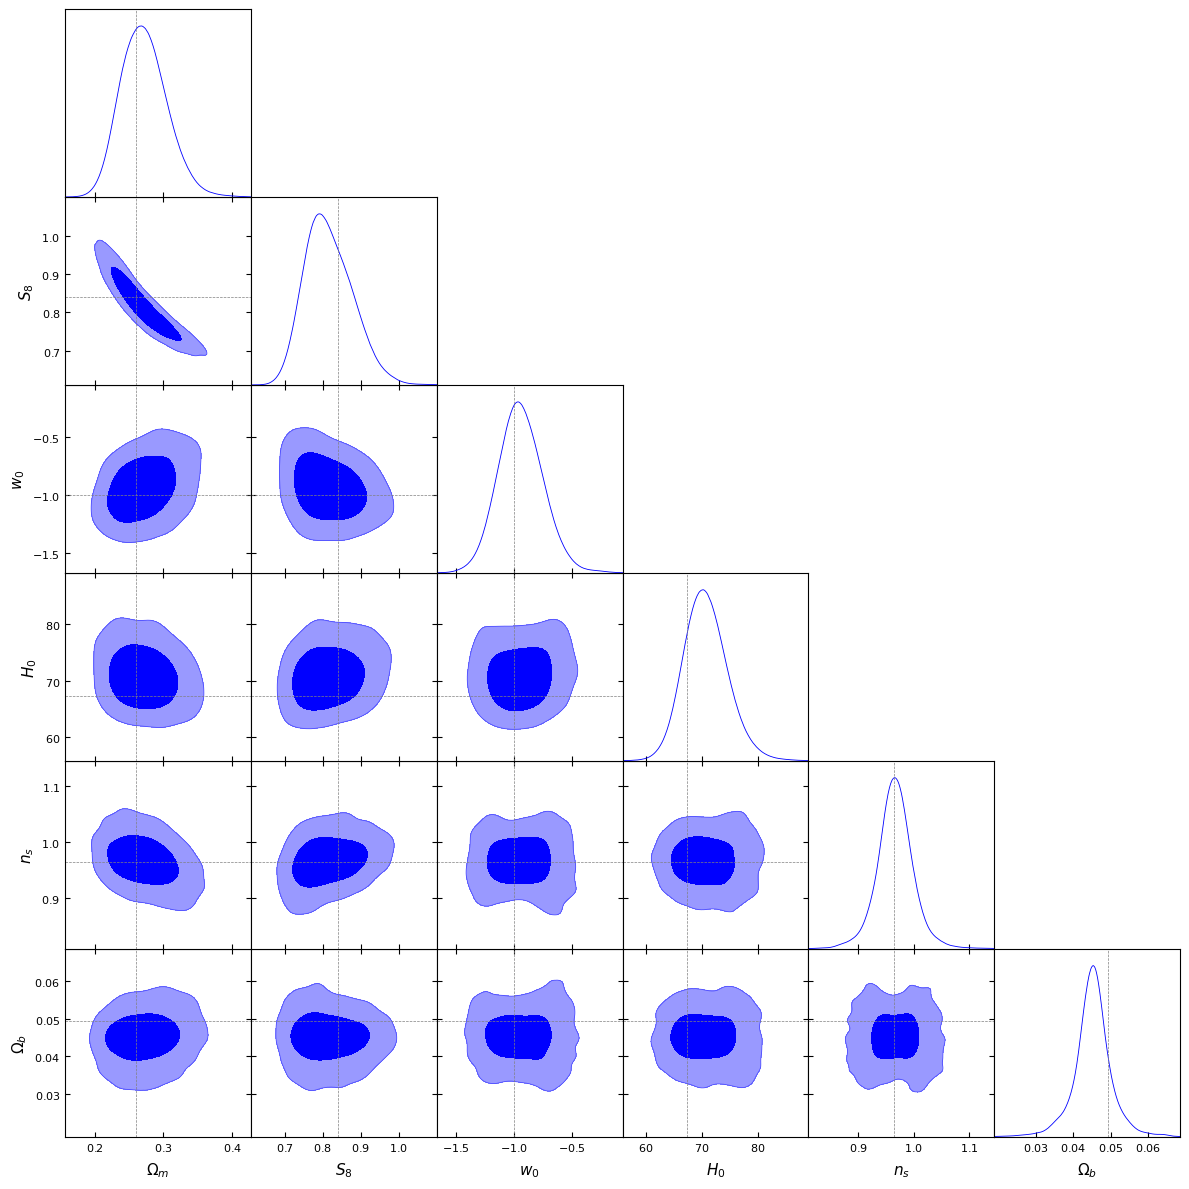

In [20]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin2_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin2, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin2_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [ ]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin2_noisy_s026_npe.npy", samples_nobar_bin2_scale1.samples)